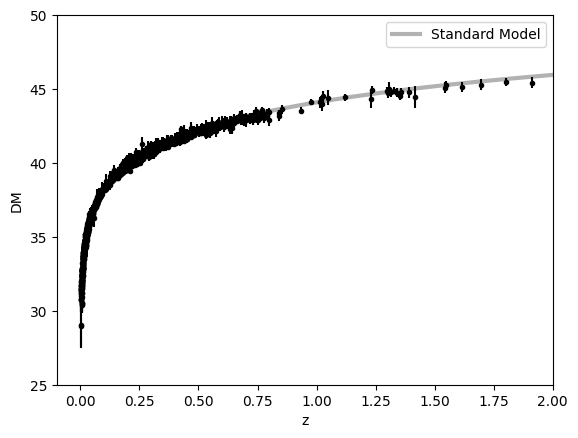

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

columns = ['zCMB', 'MU_SH0ES', 'MU_SH0ES_ERR_DIAG']
df = pd.read_csv(r'C:\Users\HP\Downloads\CTP\Cosmology project\Pantheon+SH0ES.dat', sep=r'\s+', usecols=columns, comment='#') 

z = df['zCMB'].values                # Redshift
y = df['MU_SH0ES'].values            # Distance Modulus
yerr = df['MU_SH0ES_ERR_DIAG'].values # Error bars

def H_LCDM(z, H0, Om):
    H = H0 * np.sqrt(Om*(1+z)**3 + (1-Om))
    return H

#def CPL (): 
    

def comoving_distance(z, H0, Om, c=299792.458, *args):
    E_func = lambda z_prime: np.sqrt(Om * (1 + z_prime)**3 + (1 - Om))
    integral = quad (lambda z_prime: 1.0 / E_func(z_prime, *args), 0, z)[0]
    D_H = c / H0
    D_C = D_H * integral
    return D_C


def Luminosity_distance(z, H0, Om, c=299792.458):
    D_L = (1 + z) * comoving_distance(z, H0, Om, c)
    return D_L


def Distance_modulus(z, H0, Om):
    D_L = Luminosity_distance(z, H0, Om, c=299792.458) 
    D_M = 5 * np.log10(D_L) + 25 #Distance Modulus in Mpc
    return D_M

z0 = np.linspace(0.01, np.max(z), len(z))
H_model = H_LCDM
params = (70.0, 0.3)
y_model = np.array([Distance_modulus(zi, *params) for zi in z0])

plt.errorbar(z, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(z0, y_model, "k", alpha=0.3, lw=3, label="Standard Model")
plt.xlim(-0.1, 2)
plt.ylim(25, 50)
plt.xlabel("z")
plt.ylabel("DM")
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import minimize

def log_likelihood(theta, z, y, yerr):
    H0, Om = theta
    model = np.array([Distance_modulus(zi, H0, Om) for zi in z])
    sigma2 = yerr**2 
    return -0.5 * np.sum((y - model) ** 2 / sigma2)

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args) 

initial = np.array([70.0, 0.3]) + 0.1 * np.random.randn(2)

bnds = ((50, 100), (0.01, 0.99))
soln = minimize(nll, initial, args=(z, y, yerr), bounds=bnds)

H0_ml, Om_ml = soln.x

print("Maximum likelihood estimates:")
print("H0 = {0:.3f}".format(H0_ml))
print("Om = {0:.3f}".format(Om_ml))

Maximum likelihood estimates:
H0 = 72.398
Om = 0.380


In [ ]:
import emcee

def log_prior(theta):
    H0, Om = theta
    if 50.0 < H0 < 100.0 and 0.0 < Om < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, z, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, y, yerr)

pos = soln.x + 1e-4 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(z, y, yerr))

sampler.run_mcmc(pos, 1500, progress=True);

flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(flat_samples.shape)

100%|██████████| 1500/1500 [58:39<00:00,  2.35s/it] 

(2976, 2)


<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
C:\Users\HP\AppData\Local\Temp\ipykernel_11276\3724266683.py:17: SyntaxWarning: invalid escape sequence '\m'
  txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{+{2:.3f}}}"


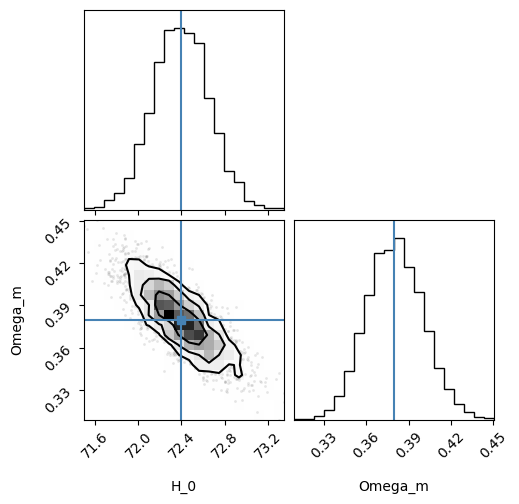

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
import corner
from IPython.display import display, Math

labels = ["H_0", "Omega_m"]

fig = corner.corner(
    flat_samples, labels=labels, truths=[H0_ml, Om_ml]
);
plt.show()

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{+{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))